In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
housing = fetch_california_housing(
    as_frame=True
)

df = housing.frame

In [3]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [5]:
df.dtypes

,0
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64


In [6]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [7]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

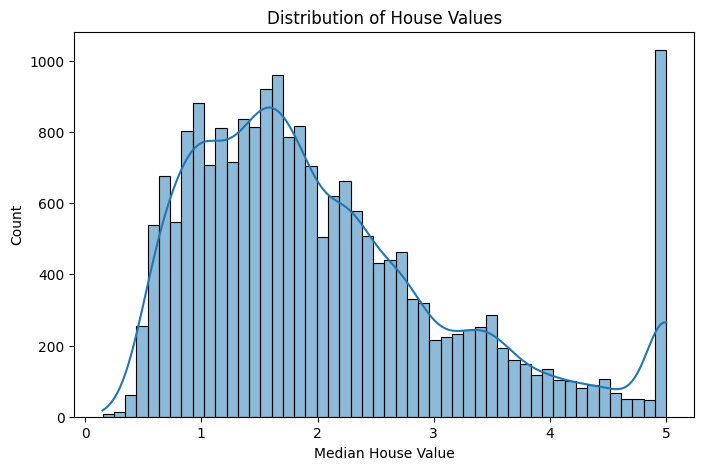

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(
    y,
    bins=50,
    kde=True
)

plt.title("Distribution of House Values")
plt.xlabel("Median House Value")
plt.show()

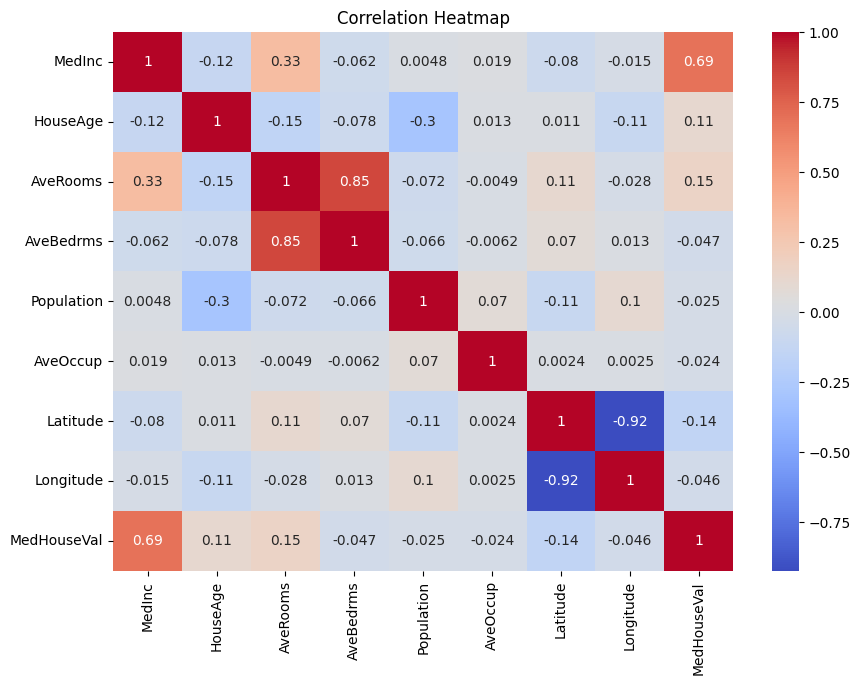

In [10]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

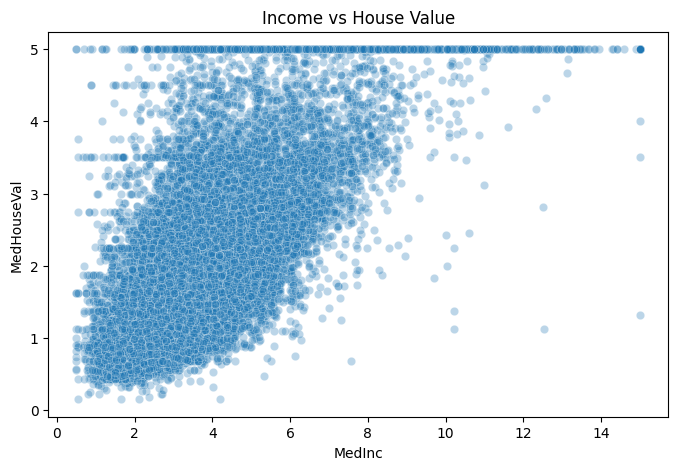

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="MedInc",
    y="MedHouseVal",
    alpha=0.3
)

plt.title("Income vs House Value")
plt.show()

In [12]:
scaler = StandardScaler()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
X_train_scaled = scaler.fit_transform(X_train)

In [16]:
X_test_scaled = scaler.transform(X_test)

In [17]:
model = keras.Sequential([

    layers.Input(
        shape=(X_train_scaled.shape[1],)
    ),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dense(
        32,
        activation="relu"
    ),

    layers.Dense(
        1
    )
])

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [20]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.0156 - mae: 0.6782 - val_loss: 0.4955 - val_mae: 0.5064
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4215 - mae: 0.4608 - val_loss: 0.4195 - val_mae: 0.4524
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3706 - mae: 0.4339 - val_loss: 0.3986 - val_mae: 0.4464
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3815 - mae: 0.4266 - val_loss: 0.3820 - val_mae: 0.4362
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3499 - mae: 0.4168 - val_loss: 0.3733 - val_mae: 0.4313
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3339 - mae: 0.4085 - val_loss: 0.3529 - val_mae: 0.4164
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3258 - mae: 0.4011 - val_loss: 0.4018 - val_mae: 0.4623
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.4684 - mae: 0.4064 - val_loss: 0.3726 - val_mae: 0.4120
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - lo

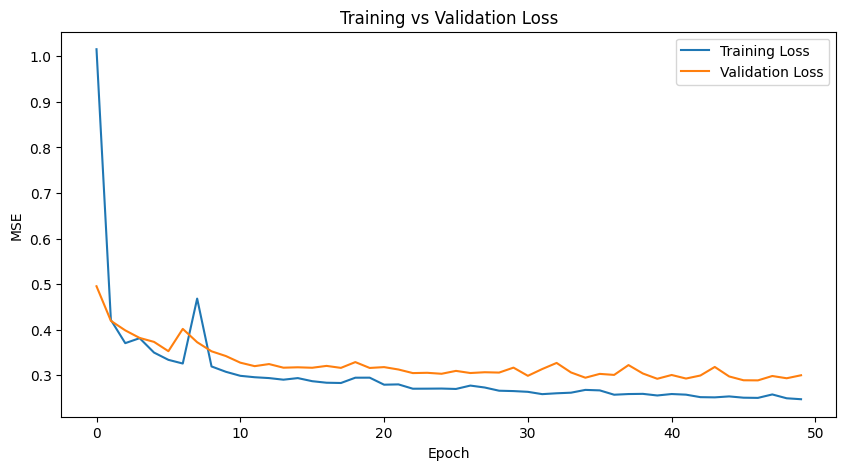

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [22]:
y_pred = model.predict(X_test_scaled)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [23]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 0.35816958166975155


In [24]:
mse = mean_squared_error(
    y_test,
    y_pred
)

print("MSE:", mse)

MSE: 0.28922421936073495


In [26]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.5377957041114544


In [27]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R² Score:", r2)

R² Score: 0.7792870591065462


In [28]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.35816958166975155
MSE : 0.28922421936073495
RMSE: 0.5377957041114544
R²  : 0.7792870591065462


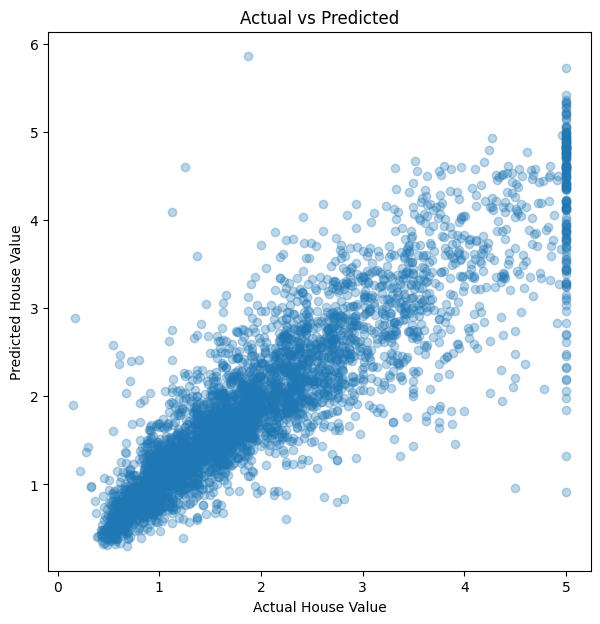

In [29]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted")

plt.show()

In [30]:
def create_baseline_model():

    model = keras.Sequential([

        layers.Input(
            shape=(X_train_scaled.shape[1],)
        ),

        layers.Dense(
            64,
            activation="relu"
        ),

        layers.Dense(
            32,
            activation="relu"
        ),

        layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

In [31]:
baseline_model = create_baseline_model()

baseline_history = baseline_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

In [32]:
baseline_pred = baseline_model.predict(
    X_test_scaled,
    verbose=0
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

print("Baseline MAE :", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²  :", baseline_r2)

Baseline MAE : 0.3683523972736518
Baseline RMSE: 0.5387847318971646
Baseline R²  : 0.7784745128080661


In [33]:
def create_dropout_model():

    model = keras.Sequential([

        layers.Input(
            shape=(X_train_scaled.shape[1],)
        ),

        layers.Dense(
            64,
            activation="relu"
        ),

        layers.Dropout(0.3),

        layers.Dense(
            32,
            activation="relu"
        ),

        layers.Dropout(0.2),

        layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

In [34]:
dropout_model = create_dropout_model()

dropout_history = dropout_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

In [35]:
dropout_pred = dropout_model.predict(
    X_test_scaled,
    verbose=0
)

dropout_mae = mean_absolute_error(
    y_test,
    dropout_pred
)

dropout_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        dropout_pred
    )
)

dropout_r2 = r2_score(
    y_test,
    dropout_pred
)

print("Dropout MAE :", dropout_mae)
print("Dropout RMSE:", dropout_rmse)
print("Dropout R²  :", dropout_r2)

Dropout MAE : 0.3882889213102963
Dropout RMSE: 0.5505776382810501
Dropout R²  : 0.7686708952635002


In [36]:
def create_batchnorm_model():

    model = keras.Sequential([

        layers.Input(
            shape=(X_train_scaled.shape[1],)
        ),

        layers.Dense(64),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.Dense(32),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

In [37]:
batchnorm_model = create_batchnorm_model()

batchnorm_history = batchnorm_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

In [38]:
batchnorm_pred = batchnorm_model.predict(
    X_test_scaled,
    verbose=0
)

batchnorm_mae = mean_absolute_error(
    y_test,
    batchnorm_pred
)

batchnorm_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        batchnorm_pred
    )
)

batchnorm_r2 = r2_score(
    y_test,
    batchnorm_pred
)

print("BatchNorm MAE :", batchnorm_mae)
print("BatchNorm RMSE:", batchnorm_rmse)
print("BatchNorm R²  :", batchnorm_r2)

BatchNorm MAE : 0.517249694531463
BatchNorm RMSE: 0.8007234028902492
BatchNorm R²  : 0.5107191887552278


In [39]:
def create_earlystop_model():

    model = keras.Sequential([

        layers.Input(
            shape=(X_train_scaled.shape[1],)
        ),

        layers.Dense(
            64,
            activation="relu"
        ),

        layers.Dense(
            32,
            activation="relu"
        ),

        layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

In [40]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [41]:
earlystop_model = create_earlystop_model()

earlystop_history = earlystop_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0
)

In [42]:
print(
    "Epochs trained:",
    len(earlystop_history.history["loss"])
)

Epochs trained: 37


In [43]:
earlystop_pred = earlystop_model.predict(
    X_test_scaled,
    verbose=0
)

earlystop_mae = mean_absolute_error(
    y_test,
    earlystop_pred
)

earlystop_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        earlystop_pred
    )
)

earlystop_r2 = r2_score(
    y_test,
    earlystop_pred
)

print("EarlyStopping MAE :", earlystop_mae)
print("EarlyStopping RMSE:", earlystop_rmse)
print("EarlyStopping R²  :", earlystop_r2)

EarlyStopping MAE : 0.36451392947963385
EarlyStopping RMSE: 0.5285352959482418
EarlyStopping R²  : 0.7868226151517247


In [44]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Dropout",
        "Batch Normalization",
        "Early Stopping"
    ],

    "MAE": [
        baseline_mae,
        dropout_mae,
        batchnorm_mae,
        earlystop_mae
    ],

    "RMSE": [
        baseline_rmse,
        dropout_rmse,
        batchnorm_rmse,
        earlystop_rmse
    ],

    "R2": [
        baseline_r2,
        dropout_r2,
        batchnorm_r2,
        earlystop_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Baseline,0.368352,0.538785,0.778475
1,Dropout,0.388289,0.550578,0.768671
2,Batch Normalization,0.517250,0.800723,0.510719
3,Early Stopping,0.364514,0.528535,0.786823


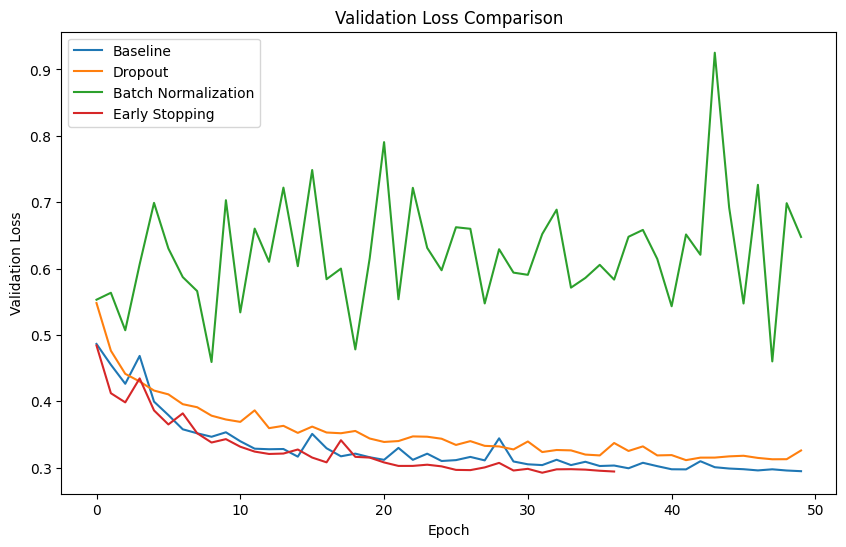

In [45]:
plt.figure(figsize=(10, 6))

plt.plot(
    baseline_history.history["val_loss"],
    label="Baseline"
)

plt.plot(
    dropout_history.history["val_loss"],
    label="Dropout"
)

plt.plot(
    batchnorm_history.history["val_loss"],
    label="Batch Normalization"
)

plt.plot(
    earlystop_history.history["val_loss"],
    label="Early Stopping"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")

plt.legend()
plt.show()

### Results and Discussion

Four ANN configurations were evaluated on the California Housing regression dataset: a baseline ANN, Dropout, Batch Normalization, and Early Stopping.

The baseline model achieved an MAE of 0.3684, an RMSE of 0.5388, and an R² score of 0.7785. After adding Dropout, the MAE and RMSE increased to 0.3883 and 0.5506, while the R² decreased to 0.7687. Therefore, Dropout did not improve the test performance in this particular experiment.

The Batch Normalization model produced an MAE of 0.5173, an RMSE of 0.8007, and an R² of 0.5107. These results were worse than the baseline, indicating that the particular Batch Normalization configuration used in this experiment was not beneficial.

The Early Stopping model achieved the lowest MAE (0.3645) and RMSE (0.5285), as well as the highest R² score (0.7868) among the tested models. This indicates that Early Stopping provided a small improvement over the baseline for this experiment.

Overall, the results show that the effectiveness of regularization and training techniques depends on the dataset and model configuration. In this experiment, Early Stopping was the most helpful technique, while Dropout and Batch Normalization did not improve the test metrics compared with the baseline.
